In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
  Using cached scienceplots-2.2.2-py3-none-any.whl.metadata (14 kB)
Using cached scienceplots-2.2.2-py3-none-any.whl (33 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
J = sp.Symbol("J", real=True, positive=True)
epsilon  = sp.Symbol("epsilon", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)
delta = sp.Symbol("delta", real=True, positive=True)
Delta1, Delta2, Delta3  = sp.symbols("Delta1 Delta2 Delta3", real=True, positive=True)
Delta31, Delta32, Delta21 = sp.symbols("Delta31 Delta32 Delta21", real=True, positive=True)
t = sp.Symbol("t", real=True, positive=True)


In [3]:
def L_eff(N, num_dimers=2):
    # building matrices
    H0 = sp.Matrix(N, N, lambda i,j : J if ({i,j} in [{2*k, 2*k+1} for k in range(num_dimers)]) else 0)
    V = sp.Matrix(N, N, lambda i,j : 0 if ({i,j} in [{2*k, 2*k+1} for k in range(num_dimers)] or i==j) else epsilon)
    
    # building lindblad jump operators
    L_operators = [sp.Matrix(N,N, lambda i,j: 1 if i==k and j==k else 0) for k in range(N)]
    
    # building lindbladians
    L0, rho = lindbladian(N, output=False, degenerate=False, H=H0, L_operators=L_operators)
    L1, _ = lindbladian(N, output=False, degenerate=False, H=V, dissipative=False)
    
    # setting all dephasing constants to the same constant gamma
    L0 = L0.subs({sp.Symbol(f"Gamma_{i}", real=True, nonnegative=True):gamma for i in range(N)})
    
    # constructing projector (and its complement)
    nullspace = [n/n.norm() for n in L0.nullspace()]
    P = sp.Add(*[  u*u.transpose() for u in nullspace  ])
    Q = sp.eye(sp.shape(P)[0]) - P

    # building Leff and Leff_red
    Leff = (-1*(Q*L1*P).conjugate().transpose()*(Q*L0*Q).pinv()*Q*L1*P).applyfunc(lambda i: i.simplify(deep=True))
    Leff_red = sp.Matrix(len(nullspace), len(nullspace), lambda i,j: (nullspace[i].transpose().conjugate()*Leff*nullspace[j])[0]).applyfunc(lambda expr: expr.simplify().apart(gamma))

    return rho, L0+L1, Leff, Leff_red


# num_dimers = 2

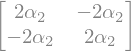

In [11]:
_, _, _, Leff_red = L_eff(N=4, num_dimers = 2)

alpha1, alpha2, alpha3 = sp.symbols("alpha1 alpha2 alpha3")

Leff_red.subs({ 2*gamma*epsilon**2 / (gamma**2 + J**2) : alpha1 , 2*epsilon**2 / gamma : alpha2 })

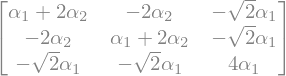

In [12]:
_, _, _, Leff_red = L_eff(N=5, num_dimers = 2)

alpha1, alpha2, alpha3 = sp.symbols("alpha1 alpha2 alpha3")

Leff_red.subs({ 2*gamma*epsilon**2 / (gamma**2 + J**2) : alpha1 , 2*epsilon**2 / gamma : alpha2 })

In [17]:
_, _, _, Leff_red = L_eff(N=6, num_dimers = 2)

alpha1, alpha2, alpha3 = sp.symbols("alpha1 alpha2 alpha3")

Leff_red = Leff_red.subs({ 2*gamma*epsilon**2 / (gamma**2 + J**2) : alpha1 , 2*epsilon**2 / gamma : alpha2 })

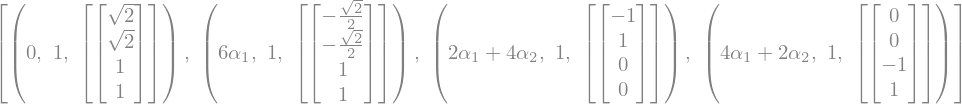

In [19]:
Leff_red.eigenvects()

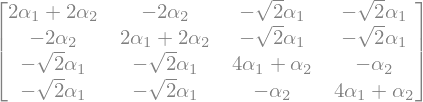

In [10]:
Leff_red

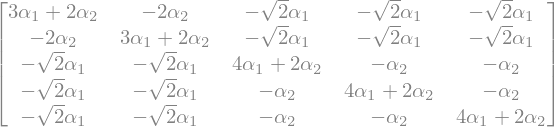

In [25]:
_, _, _, Leff_red = L_eff(N=7, num_dimers = 2)

alpha1, alpha2, alpha3 = sp.symbols("alpha1 alpha2 alpha3")

Leff_red = Leff_red.subs({ 2*gamma*epsilon**2 / (gamma**2 + J**2) : alpha1 , 2*epsilon**2 / gamma : alpha2 })
Leff_red

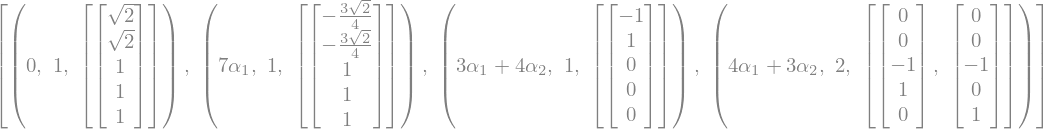

In [26]:
Leff_red.eigenvects()

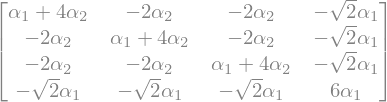

In [29]:
_, _, _, Leff_red = L_eff(N=7, num_dimers = 3)

alpha1, alpha2, alpha3 = sp.symbols("alpha1 alpha2 alpha3")

Leff_red = Leff_red.subs({ 2*gamma*epsilon**2 / (gamma**2 + J**2) : alpha1 , 2*epsilon**2 / gamma : alpha2 })
Leff_red

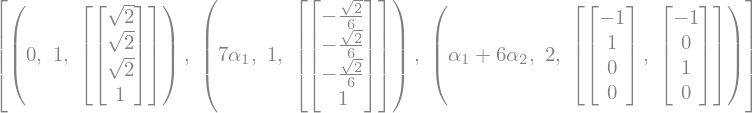

In [30]:
Leff_red.eigenvects()

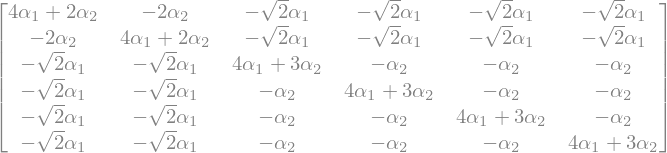

In [27]:
_, _, _, Leff_red = L_eff(N=8, num_dimers = 2)

alpha1, alpha2, alpha3 = sp.symbols("alpha1 alpha2 alpha3")

Leff_red = Leff_red.subs({ 2*gamma*epsilon**2 / (gamma**2 + J**2) : alpha1 , 2*epsilon**2 / gamma : alpha2 })
Leff_red

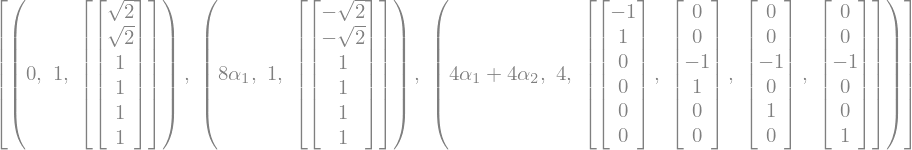

In [28]:
Leff_red.eigenvects()

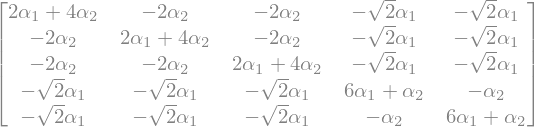

In [16]:
_, _, _, Leff_red = L_eff(N=8, num_dimers = 3)

alpha1, alpha2, alpha3 = sp.symbols("alpha1 alpha2 alpha3")

Leff_red.subs({ 2*gamma*epsilon**2 / (gamma**2 + J**2) : alpha1 , 2*epsilon**2 / gamma : alpha2 })

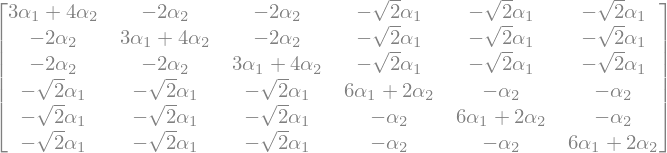

In [23]:
_, _, _, Leff_red = L_eff(N=9, num_dimers = 3)

alpha1, alpha2, alpha3 = sp.symbols("alpha1 alpha2 alpha3")

Leff_red = Leff_red.subs({ 2*gamma*epsilon**2 / (gamma**2 + J**2) : alpha1 , 2*epsilon**2 / gamma : alpha2 })
Leff_red

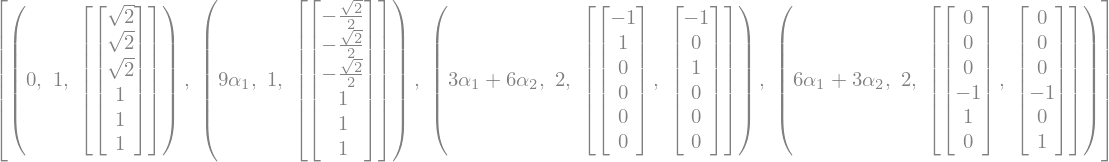

In [24]:
Leff_red.eigenvects()

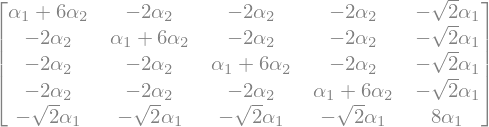

In [18]:
_, _, _, Leff_red = L_eff(N=9, num_dimers = 4)

alpha1, alpha2, alpha3 = sp.symbols("alpha1 alpha2 alpha3")

Leff_red.subs({ 2*gamma*epsilon**2 / (gamma**2 + J**2) : alpha1 , 2*epsilon**2 / gamma : alpha2 })

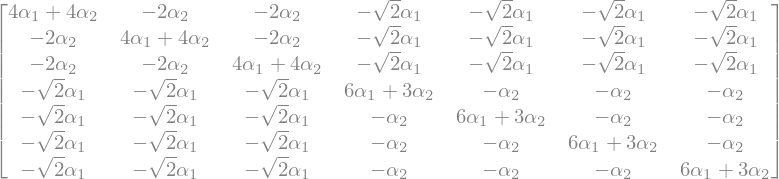

In [19]:
_, _, _, Leff_red = L_eff(N=10, num_dimers = 3)

alpha1, alpha2, alpha3 = sp.symbols("alpha1 alpha2 alpha3")

Leff_red.subs({ 2*gamma*epsilon**2 / (gamma**2 + J**2) : alpha1 , 2*epsilon**2 / gamma : alpha2 })

In [9]:
_, L, Leff, Leff_red = L_eff(N=6, num_dimers = 2)

alpha1, alpha2, alpha3 = sp.symbols("alpha1 alpha2 alpha3")

mathematica_code(L).replace("Gamma","Γ").replace("epsilon", "ϵ")

'{{0, I*J, I*ϵ, I*ϵ, I*ϵ, I*ϵ, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0}, {I*J, -Γ, I*ϵ, I*ϵ, I*ϵ, I*ϵ, 0, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0}, {I*ϵ, I*ϵ, -Γ, I*J, I*ϵ, I*ϵ, 0, 0, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0}, {I*ϵ, I*ϵ, I*J, -Γ, I*ϵ, I*ϵ, 0, 0, 0, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0}, {I*ϵ, I*ϵ, I*ϵ, I*ϵ, -Γ, I*ϵ, 0, 0, 0, 0, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0}, {I*ϵ, I*ϵ, I*ϵ, I*ϵ, I*ϵ, -Γ, 0, 0, 0, 0, 0, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ}, {-I*J, 0, 0, 0, 0, 0, -Γ, I*J, I*ϵ, I*ϵ, I*ϵ, I*ϵ, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0}, {0, -I*J, 0, 0, 0, 0, I*J, 0, I*ϵ, I*ϵ, I*ϵ, I*

In [4]:
N = 7
num_dimers = 2


H0 = sp.Matrix(N, N, lambda i,j : J if ({i,j} in [{2*k, 2*k+1} for k in range(num_dimers)]) else 0)
V = sp.Matrix(N, N, lambda i,j : 0 if ({i,j} in [{2*k, 2*k+1} for k in range(num_dimers)] or i==j) else epsilon)

# building lindblad jump operators
L_operators = [sp.Matrix(N,N, lambda i,j: 1 if i==k and j==k else 0) for k in range(N)]

# building lindbladians
L0, rho = lindbladian(N, output=False, degenerate=False, H=H0, L_operators=L_operators)
L1, _ = lindbladian(N, output=False, degenerate=False, H=V, dissipative=False)

# setting all dephasing constants to the same constant gamma
L0 = L0.subs({sp.Symbol(f"Gamma_{i}", real=True, nonnegative=True):gamma for i in range(N)})

# constructing projector (and its complement)
nullspace = [n/n.norm() for n in L0.nullspace()]
P = sp.Add(*[  u*u.transpose() for u in nullspace  ])
Q = sp.eye(sp.shape(P)[0]) - P

# building Leff and Leff_red
Leff = (-1*(Q*L1*P).conjugate().transpose()*(Q*L0*Q).pinv()*Q*L1*P).applyfunc(lambda i: i.simplify(deep=True))
Leff_red = sp.Matrix(len(nullspace), len(nullspace), lambda i,j: (nullspace[i].transpose().conjugate()*Leff*nullspace[j])[0]).applyfunc(lambda expr: expr.simplify().apart(gamma))

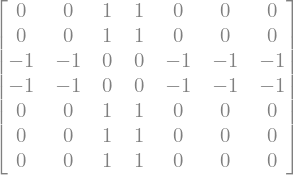

In [5]:
(L1*nullspace[1]).reshape(N,N)/(-1*sp.I*epsilon/sp.sqrt(2))

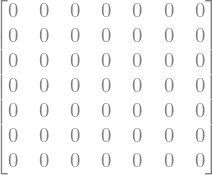

In [6]:
(L0*nullspace[0]).reshape(N,N)

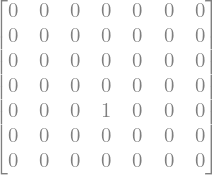

In [7]:
c = sp.zeros(N,N)
c[4,3]=1
c

In [8]:
L0inv = (Q*L0*Q).pinv()

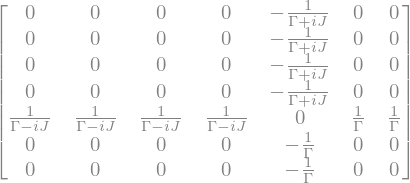

In [12]:
((L0inv*L1*nullspace[2]).reshape(N,N)/(-1*sp.I*epsilon)).applyfunc(lambda i : i.simplify(deep=True))

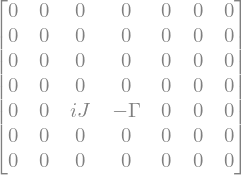

In [10]:
(L0*c.reshape(N**2, 1)).reshape(N,N)

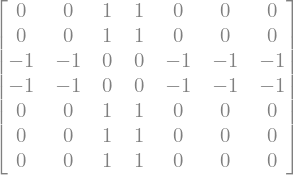

In [20]:
(L1*nullspace[1]/(-1*sp.I*epsilon/sp.sqrt(2))).reshape(N,N)